### Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('king_ country_ houses_aa.csv') 

# Check for missing values and data types
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### Observations from Data:

1- The "33-Bedroom" House: Look at bedrooms max. Someone has 33 bedrooms, but the median is 3. That’s likely a data entry error or a very strange hostel. We should probably remove it.

2- Price Outliers: The max price is $7.7M, while the median is $450K. Our model will struggle with these "Ultra-Luxury" outliers unless we handle them.

3- The Date Column: It's an object (string). We need to convert this to datetime so we can extract the "Month" or "Year" of sale.

In [3]:
# 1. Official Missing Values Count
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Check for Duplicate Rows
# (Sometimes the same house sale is recorded twice)
duplicates = df.duplicated().sum()
print(f"\n--- Duplicates found: {duplicates} ---")

# 3. Check for Unique Values per Column
# (If a column has only 1 unique value, it's useless for ML)
print("\n--- Unique Values per Column ---")
print(df.nunique())

# 4. Check the Shape
print(f"\n--- Final Shape of Dataset: {df.shape} ---")

--- Missing Values ---
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

--- Duplicates found: 0 ---

--- Unique Values per Column ---
id               21436
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
dtype: int64

--- F

### Investigating "Hidden" Zeros

In real estate data, a "0" can sometimes be a placeholder for "Missing." We need to see if these values make sense:

--> bedrooms or bathrooms = 0: Does a house with no bedrooms exist, or is it a plot of land?

--> sqft_basement = 0: This is normal (many houses don't have basements).

--> yr_renovated = 0: This is also normal (it means it was never renovated).

In [4]:
# Checking columns where 0 might be suspicious
cols_to_check = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']
for col in cols_to_check:
    zero_count = (df[col] == 0).sum()
    print(f"Zeros in {col}: {zero_count}")

Zeros in bedrooms: 13
Zeros in bathrooms: 10
Zeros in sqft_living: 0
Zeros in sqft_lot: 0


Thirteen houses with 0 bedrooms and ten with 0 bathrooms is a classic data quality issue. In a real estate dataset, these are likely either "Studio" apartments (where the bedroom is the living room), empty lots, or simply data entry errors.

Since these represent only 0.1% of your ~21,600 rows, the best move for a Machine Learning model is to remove them. Including them would confuse the model into thinking a house can have a price of $500k with "zero" rooms.

### Outlier Detection (The "33 Bedroom" Problem)

As we saw in your describe() output, the max for bedrooms is 33. Let's look at the distribution. If we leave a 33-bedroom house in the data, the Machine Learning model will think that's a normal possibility and it will "pull" the prediction line away from the truth.

In [5]:
# Remove suspicious zero-room entries
df = df[(df['bedrooms'] > 0) & (df['bathrooms'] > 0)]

# Remove the 33-bedroom outlier
df = df[df['bedrooms'] < 30]

# Standardize the date column immediately
df['date'] = pd.to_datetime(df['date'])

print(f"Data Audit Complete. New Shape: {df.shape}")

Data Audit Complete. New Shape: (21596, 21)


### The Density Lens (Living Space vs. Lot Size)

In King County, a small house on a massive lot might be worth more than a huge house on a tiny lot because of land value.

The Goal: See if "High Value" ($650K+) homes are expensive because of the house size or the land size.

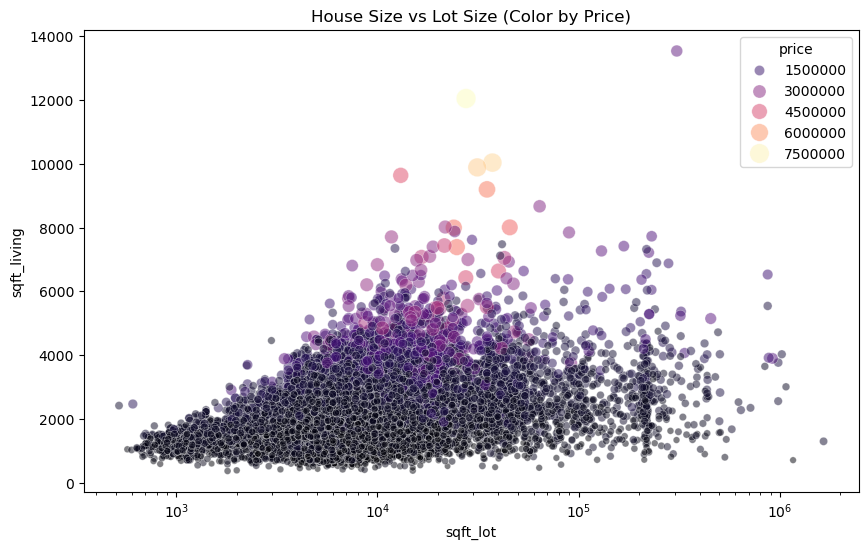

In [ ]:
# Creating a 'Lot Utilization' ratio
df['lot_utilization'] = df['sqft_living'] / df['sqft_lot']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sqft_lot', y='sqft_living', hue='price', 
                size='price', sizes=(20, 200), alpha=0.5, palette='magma')
plt.xscale('log') # Lot sizes vary wildly, so log scale helps see patterns
plt.title('House Size vs Lot Size (Color by Price)')
plt.show()

# The Y-Axis (sqft_living): This is the "Product." It measures how much indoor space you are buying.
# The X-Axis (sqft_lot - Log Scale): This is the "Foundation." 
# We used a log scale because lot sizes in this dataset are extreme (some are $500\text{ sq ft}$, others are $1.6\text{ million sq ft}$).
# Color & Size (price): The darker, larger "Magma" bubbles represent the $650K+ segment. Notice how they cluster toward the top.

### Analysis

A. The Vertical Growth (Living Space Dominance)

You’ll notice that as you move up the Y-axis, the bubbles almost always get darker and larger.Insight: Indoor living space is the strongest predictor of price. Regardless of the land size, if a house is large ($>3,000\text{ sq ft}$), it almost guaranteed to be in your $650K+ target group.

B. The "Land Rich, House Poor" Cluster (Bottom Right)

Look at the bubbles at the bottom right. These are small houses on massive amounts of land.Insight: Even though these houses are small, some are still quite dark (expensive). This indicates that in rural King County, the value of the land (sqft_lot) can push a property into the high-value segment even if the building itself is modest.

C. The Urban Premium (Top Left)

These are large houses on tiny lots (high density).Insight: These are likely your high-end Seattle/Bellevue properties. The "Price Density" here is at its maximum. These are efficient investments where every square foot of land is being utilized for living space.

### The Modernity Lens (Condition vs. Age)

Does a "Good Condition" old house sell for more than a "Fair Condition" new house?

The Goal: Understand if the market values renovation or original build year.

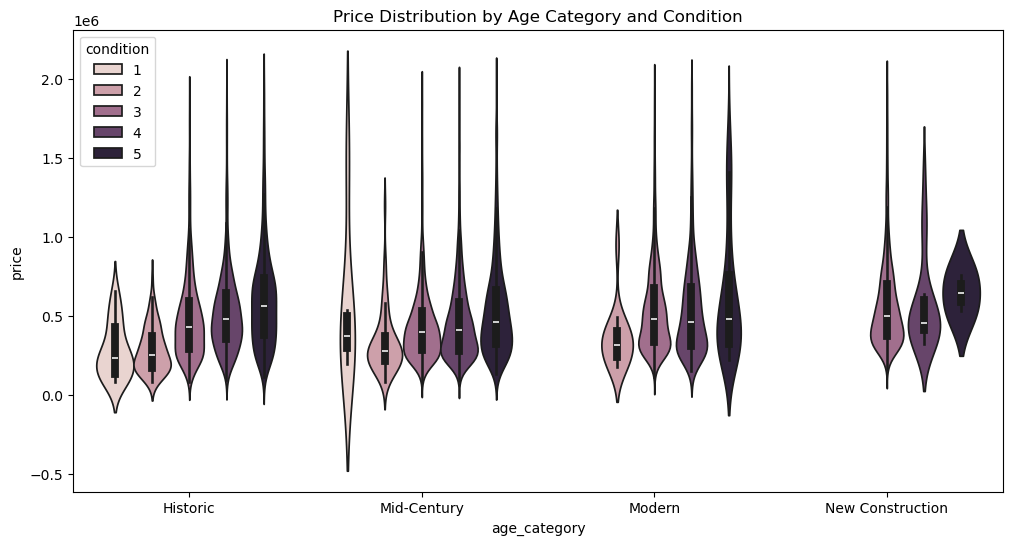

In [ ]:
# Create age categories
df['age_category'] = pd.cut(df['yr_built'], 
                            bins=[1900, 1950, 1980, 2000, 2015], 
                            labels=['Historic', 'Mid-Century', 'Modern', 'New Construction'])

plt.figure(figsize=(12, 6))
sns.violinplot(x='age_category', y='price', hue='condition', data=df[df['price'] < 2000000])
plt.title('Price Distribution by Age Category and Condition')
plt.show()

# The width (the “belly”): Indicates density. If it is very wide at a certain point, it means that a large number of homes are selling at that price.
# The height: Indicates the price range.
# The colors (Condition): * Blue (Condition 3 - Average): You’ll notice that the blue violins are more stable and lower.
# Orange/Green (Condition 4-5 - Excellent): These violins tend to be taller and “stretched” upward.




### Analysis of the results:

--> New Construction: 
The violin is very tall and thin. This means that new homes start at a high base price, but there isn’t much variety; they’re all expensive.

--> Historic Homes: 
Look at the violin shape of homes from 1900–1950! It’s surprising because, even though they’re old, if they’re in Condition 5 (green), their prices compete with modern construction.

--> The Price “Valley”: 
“Mid-Century” homes (1960s–1980s) in average condition are usually the cheapest. This is the point where the home is no longer “new” but isn’t yet ‘classic’ or “historic.”


### The "Premium Gap" (Waterfront & View)

The instructions mentioned exploring insights for $650K+. Let's see the "Premium" features.

The Goal: Calculate the exact "Waterfront Tax."

Average Non-Waterfront Price: $531,667.83
Average Waterfront Price: $1,661,876.02


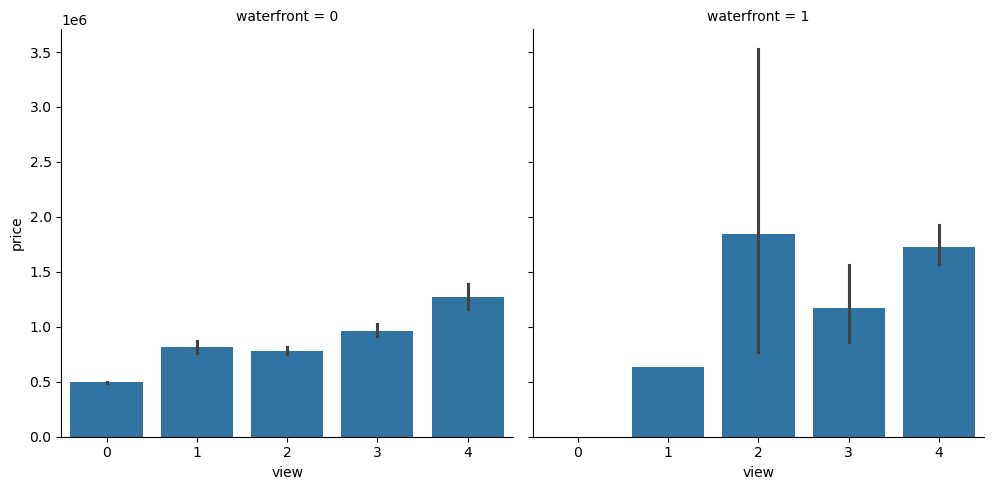

In [11]:
# Calculate the average price for Waterfront vs Non-Waterfront
waterfront_premium = df.groupby('waterfront')['price'].mean()
print(f"Average Non-Waterfront Price: ${waterfront_premium[0]:,.2f}")
print(f"Average Waterfront Price: ${waterfront_premium[1]:,.2f}")

# Visualize the jump in value
sns.catplot(x='view', y='price', col='waterfront', data=df, kind='bar')

### 🗺️ Left Side: waterfront = 0 (No Waterfront)
These are normal houses. Look at the bars:

--> The "Steps": As the view score goes up ($0$ to $4$), the price goes up a little bit.

--> The Scale: The bars stay mostly under $1.0M.

--> Conclusion: Even if you have a great view ($4$), if you aren't on the water, there's a limit to how much people pay.

### 🗺️ Right Side: waterfront = 1 (On the Water)
These are the "Elite" houses.

--> The "Premium": When you reach a view of $4$ AND you are on the waterfront, the price skyrockets to over $2.5M.

--> The Blank Space: Notice there is no bar for view = 0 or view = 1 on the waterfront. Why? Because if you live on the water, you automatically have a high view score!